# Price Prediction Model

Building a regression model to predict property price from listing features.
This is basically the "scheme success" idea from the project doc but applied to
individual listings instead of a whole scheme, since I don't have lead/booking
data at the scheme level - just listing-level data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("../data/processed/cleaned_listings.csv")
print(df.shape)
df.head()


(12359, 28)


,location,area,price,price_currency,status,new/resale,price_negotiable,description,security_deposit,facing,...,Swimming Pool,Sports Facility,Jogging Track,Landscaped Gardens,locality_score,Car Parking,city,property_type,price_per_sqft,amenity_count
0,Dhakoli,1300.0,2850000.0,INR,Unknown,0.0,0.0,This spacious 2 bhk builder floor is available...,1.0,Unknown,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,2192.31,0
1,Dhakoli,1400.0,3600000.0,INR,Unknown,0.0,0.0,It’s a 3 bhk builder floor situated in Dhakoli...,1.0,Unknown,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,2571.43,0
2,Dhakoli,1350.0,3690000.0,INR,Unknown,0.0,0.0,It has an area of 1350 sqft with a carpet area...,1.0,Northeast,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,2733.33,0
3,New Chandigarh Mohali,1200.0,10000000.0,INR,Unknown,0.0,0.0,It has a salable area of 1200 sqft and is avai...,1.0,Northeast,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,8333.33,0
4,Sunny Enclave,1008.0,3090000.0,INR,Unknown,1.0,0.0,This spacious 2 bhk builder floor is available...,1.0,East,...,0,0,0,0,9.1,0.0,Chandigarh,Builderfloor,3065.48,0


## quick eda

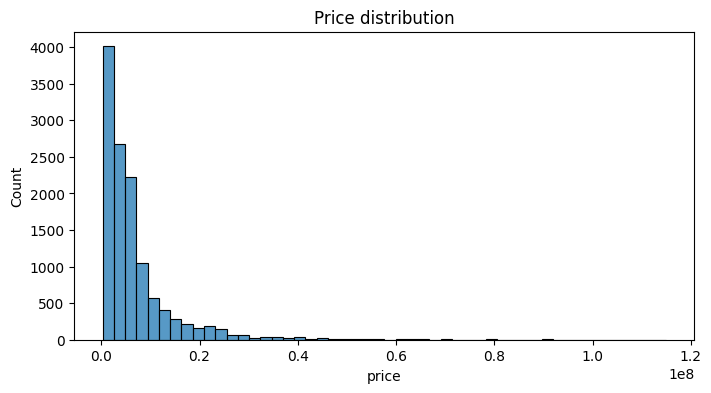

In [2]:
plt.figure(figsize=(8,4))
sns.histplot(df["price"], bins=50)
plt.title("Price distribution")
plt.show()


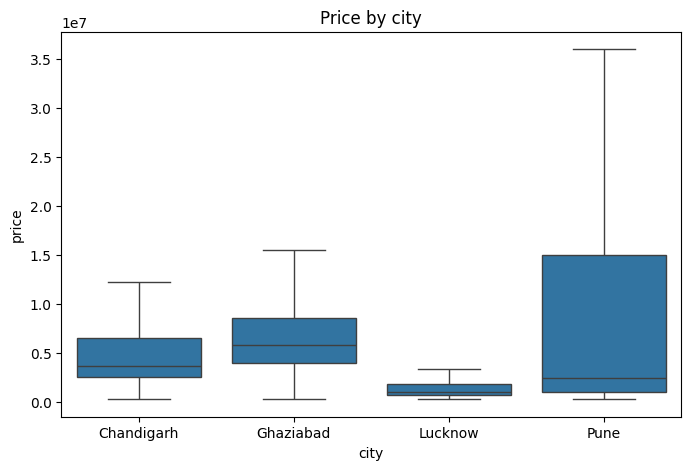

In [3]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="city", y="price", showfliers=False)
plt.title("Price by city")
plt.show()


In [4]:
df["area"].corr(df["price"])


np.float64(0.7018915715878835)

price is pretty skewed, going to log transform it before modeling - should help the linear models especially

## picking features

In [5]:
drop_cols = ["description", "price_currency", "price_per_sqft", "location"]
drop_cols = [c for c in drop_cols if c in df.columns]

model_df = df.drop(columns=drop_cols)

cat_cols = ["city", "property_type", "facing", "status"]
cat_cols = [c for c in cat_cols if c in model_df.columns]

num_cols = [c for c in model_df.columns if c not in cat_cols + ["price"]]

print("categorical:", cat_cols)
print("numeric:", num_cols)


categorical: ['city', 'property_type', 'facing', 'status']
numeric: ['area', 'new/resale', 'price_negotiable', 'security_deposit', 'furnished', 'age of property', 'Lift(s)', 'Full Power Backup', '24 X 7 Security', "Children's play area", 'Club House', 'Gymnasium', 'Swimming Pool', 'Sports Facility', 'Jogging Track', 'Landscaped Gardens', 'locality_score', 'Car Parking', 'amenity_count']


In [6]:
model_df = pd.get_dummies(model_df, columns=cat_cols, drop_first=True)

# a couple of numeric cols still have some NaNs, filling with median
for c in num_cols:
    if model_df[c].isna().any():
        model_df[c] = model_df[c].fillna(model_df[c].median())

model_df["log_price"] = np.log1p(model_df["price"])
model_df.shape


(12359, 36)

In [7]:
feature_cols = [c for c in model_df.columns if c not in ["price", "log_price"]]

X = model_df[feature_cols]
y = model_df["log_price"]
y_actual_price = model_df["price"]

X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(
    X, y, y_actual_price, test_size=0.2, random_state=42
)

scaler = StandardScaler()
num_features_present = [c for c in num_cols if c in X_train.columns]
X_train[num_features_present] = scaler.fit_transform(X_train[num_features_present])
X_test[num_features_present] = scaler.transform(X_test[num_features_present])

X_train.shape, X_test.shape


((9887, 34), (2472, 34))

## training the regression models we covered - linear, ridge, lasso, decision tree, random forest

In [8]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    pred_price = np.expm1(pred_log)
    pred_price = np.clip(pred_price, 0, None)

    mae = mean_absolute_error(price_test, pred_price)
    rmse = np.sqrt(mean_squared_error(price_test, pred_price))
    r2 = r2_score(price_test, pred_price)

    results[name] = {"model": model, "mae": mae, "rmse": rmse, "r2": r2}
    print(f"{name}: MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.3f}")


Linear Regression: MAE=3,150,461  RMSE=14,803,737  R2=-2.387
Ridge: MAE=3,149,081  RMSE=14,784,711  R2=-2.378
Lasso: MAE=2,972,889  RMSE=12,325,859  R2=-1.348
Decision Tree: MAE=1,720,921  RMSE=4,045,265  R2=0.747


Random Forest: MAE=1,378,939  RMSE=3,257,628  R2=0.836


In [9]:
results_df = pd.DataFrame({k: {m: v[m] for m in ["mae","rmse","r2"]} for k, v in results.items()}).T
results_df = results_df.sort_values("r2", ascending=False)
results_df


,mae,rmse,r2
Random Forest,1.378939e+06,3.257628e+06,0.835987
Decision Tree,1.720921e+06,4.045265e+06,0.747089
Lasso,2.972889e+06,1.232586e+07,-1.348057
Ridge,3.149081e+06,1.478471e+07,-2.378312
Linear Regression,3.150461e+06,1.480374e+07,-2.387013


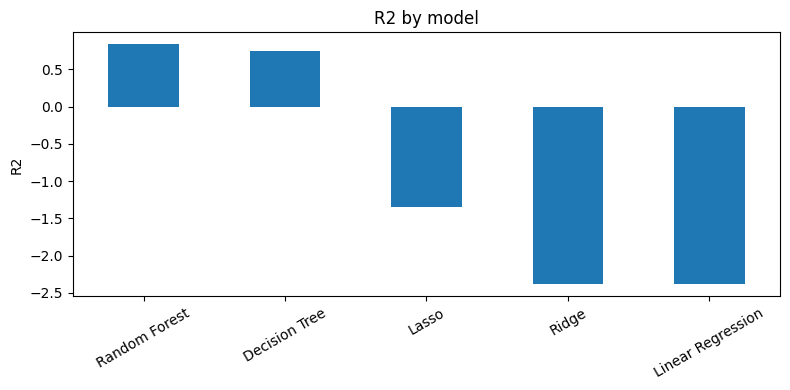

In [10]:
plt.figure(figsize=(8,4))
results_df["r2"].plot(kind="bar")
plt.title("R2 by model")
plt.ylabel("R2")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## best model - predicted vs actual

best model: Random Forest


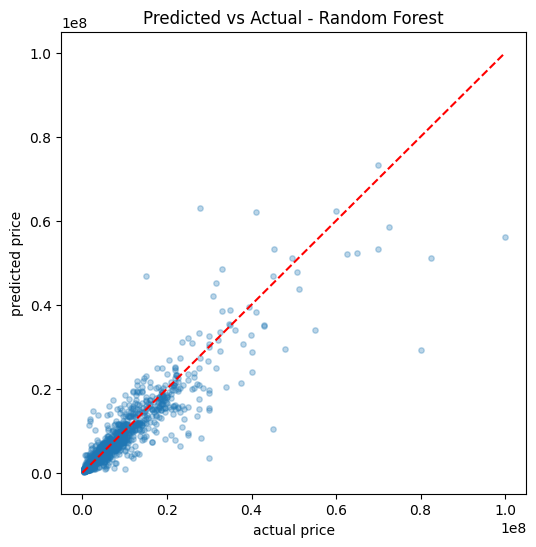

In [11]:
best_name = results_df.index[0]
best_model = results[best_name]["model"]
print("best model:", best_name)

pred_log = best_model.predict(X_test)
pred_price = np.clip(np.expm1(pred_log), 0, None)

plt.figure(figsize=(6,6))
sample_idx = np.random.choice(len(price_test), min(2000, len(price_test)), replace=False)
plt.scatter(price_test.values[sample_idx], pred_price[sample_idx], alpha=0.3, s=15)
max_val = max(price_test.max(), pred_price.max())
plt.plot([0, max_val], [0, max_val], "r--")
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title(f"Predicted vs Actual - {best_name}")
plt.show()


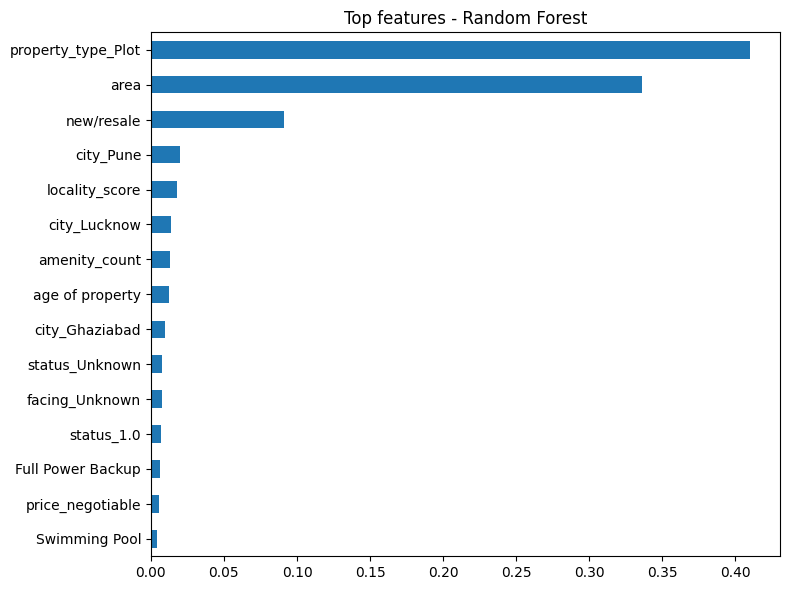

In [12]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
    importances.sort_values(ascending=False).head(15).sort_values().plot(kind="barh", figsize=(8,6))
    plt.title(f"Top features - {best_name}")
    plt.tight_layout()
    plt.show()


## saving the model

In [13]:
import joblib

joblib.dump(best_model, "../models/price_model.pkl")
joblib.dump(scaler, "../models/price_scaler.pkl")
joblib.dump(feature_cols, "../models/price_model_columns.pkl")

print("saved:", best_name)


saved: Random Forest


## notes

- area and city ended up being the biggest drivers of price which makes sense
- random forest usually beats the linear models here since price doesn't move linearly with area/amenities
- R2 isn't amazing (~0.8ish) - probably because we're missing some important features like exact locality within a city, which we don't have in this dataset
